# Regression Analysis

This notebook uses the previously cleaned datasets for gas and electricity usage and provides a regression analysis of the data.

Available DataFrames:
- `gas_monthly_usage`
- `electric_monthly_usage`

### Accessing the dataset

First, equivalently to how data was fetched in the eda notebook, fetch the data for gas usage and electricity usage and save the data as dataframes. Also do a visual check of imported data.

In [2]:
from pathlib import Path

import pandas as pd


def find_project_root() -> Path:
    """Walk upward until the repository root containing data/clean is found."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "clean").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing data/clean.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "clean"

gas_monthly_usage = pd.read_csv(
    DATA_DIR / "gas_monthly_usage.csv",
    parse_dates=["month"],
)

electric_monthly_usage = pd.read_csv(
    DATA_DIR / "electric_monthly_usage.csv",
    parse_dates=["month"],
)

print(f"Loaded gas data: {gas_monthly_usage.shape[0]:,} rows x {gas_monthly_usage.shape[1]} columns")
print(
    f"Loaded electricity data: {electric_monthly_usage.shape[0]:,} rows x {electric_monthly_usage.shape[1]} columns"
)

display(gas_monthly_usage.head())
display(electric_monthly_usage.head())

Loaded gas data: 8,412 rows x 6 columns
Loaded electricity data: 19,656 rows x 6 columns


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-01-01,23839.31
1,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-02-01,18735.80
2,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-03-01,14082.81
3,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-04-01,11537.50
4,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-05-01,7784.48


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-01-01,3294191.84
1,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-02-01,3188060.05
2,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-03-01,2971166.22
3,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-04-01,2861591.94
4,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-05-01,3142472.63


### Additional Data cleaning
- Filter the dataframes to include only pertinent columns (features and the output variable).
- Drop rows with placeholder values for the gross floor are (i.e. where the GFA = 1)


In [21]:
# Only include relavent columns for gas and electricity usage
gas_usage_for_regression = gas_monthly_usage[["Gross Floor Area", "month", "Property Type - Self-Selected", "normalized_monthly_usage"]].copy()
electricity_usage_for_regression = electric_monthly_usage[["Gross Floor Area", "month", "Property Type - Self-Selected", "normalized_monthly_usage"]].copy()

# Add month_name column to the dataset
gas_usage_for_regression['month'] = pd.to_datetime(gas_usage_for_regression['month'])
gas_usage_for_regression['month_name'] = gas_usage_for_regression['month'].dt.month_name().copy()

electricity_usage_for_regression['month'] = pd.to_datetime(electricity_usage_for_regression['month'])
electricity_usage_for_regression['month_name'] = electricity_usage_for_regression['month'].dt.month_name().copy()

# Drop NA values
gas_usage_for_regression = gas_usage_for_regression.dropna(
    subset=["Gross Floor Area", "normalized_monthly_usage"]
)

electricity_usage_for_regression = electricity_usage_for_regression.dropna(
    subset=["Gross Floor Area", "normalized_monthly_usage"]
)

# Remove placeholder Gross Floor Area = 1
gas_usage_for_regression = gas_usage_for_regression[
    gas_usage_for_regression["Gross Floor Area"] != 1
]

electricity_usage_for_regression = electricity_usage_for_regression[
    electricity_usage_for_regression["Gross Floor Area"] != 1
]

#display(electricity_usage_for_regression.head())
#display(gas_usage_for_regression.head())

print(len(gas_usage_for_regression["normalized_monthly_usage"]))
print(len(gas_usage_for_regression["Gross Floor Area"]))

# gas_usage_for_regression = pd.get_dummies(gas_usage_for_regression, columns=['month_name'])

8052
8052


### Simple regression analysis only using GFA and monthly usage

First we will conduct a simple regression analysis, utilizing the GFA (feature) and monthly usage (output) variables alone.  Based on the scatterplot from the EDA notebook, we expect this analysis to be "unfulfilling".

In [ ]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

x = gas_usage_for_regression["Gross Floor Area"].to_numpy().reshape(-1, 1)
y = gas_usage_for_regression["normalized_monthly_usage"].to_numpy().reshape(-1, 1)

#Split the dataset into training and test data, test_size will be 15% of cleaned data, and select a random state to reproduce results.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=28)

#Run the regression using test data
simple_gas_regression = linear_model.LinearRegression()
simple_gas_regression.fit(x_train, y_train)

#predict y values using test values for x
y_pred = simple_gas_regression.predict(x_test)

#generate MSE and r2_score
mse = mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

print("Cofficients (only 1):", simple_gas_regression.coef_[0])
print("Intercept:", simple_gas_regression.intercept_)

print("MSE:", mse)
print("R2 score:", r2_score)


Cofficients (only 1): [0.16336148]
Intercept: [1140.20987134]
MSE: 961501300.4589884
R2 score: 0.12603625410689945


Results are lackluster but unsurprising, MSE: 961501300.4589884 (very large) while R2 score: 0.12603625410689945 (quite small), indicating the model was not a very good fit. A simple visualization will solidify this fact.

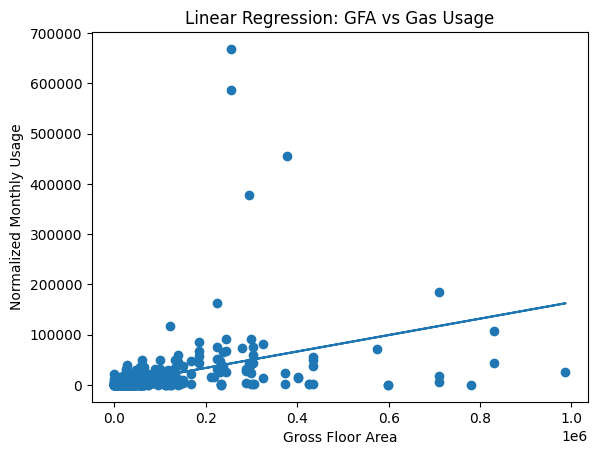

In [30]:
import matplotlib.pyplot as plt

plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred)

plt.xlabel("Gross Floor Area")
plt.ylabel("Normalized Monthly Usage")
plt.title("Linear Regression: GFA vs Gas Usage")

plt.show()

The presence of outliers may be skewing the model, creating a positive slope.